# Tuần 03 — Thực hành kNN: 4 bài

Demo `01_Demo-kNN.ipynb` dừng ở việc **vote nhãn cho một mẫu test**.

Notebook này có **4 bài**. Mỗi bài là một bộ dữ liệu trên Kaggle. Cả 4 bài đều làm.

Viết hàm kNN một lần ở phần chung (NumPy, không dùng `KNeighborsClassifier`), rồi áp vào từng bài. Điền các ô có `???`. Giữ `np.random.seed(3000)`.

Tải đủ 4 file, đặt vào thư mục `data/`:

| Bài | Bộ dữ liệu | Link | File |
|---|---|---|---|
| 1 | Iris Species | https://www.kaggle.com/datasets/uciml/iris | `data/Iris.csv` |
| 2 | Palmer Penguins | https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data | `data/penguins_size.csv` |
| 3 | Heart Failure Prediction | https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction | `data/heart.csv` |
| 4 | Mushroom Classification | https://www.kaggle.com/datasets/uciml/mushroom-classification | `data/mushrooms.csv` |


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import LabelEncoder

np.set_printoptions(precision=3, suppress=True)


## Phần chung — hàm kNN

Các bài bên dưới gọi lại 4 hàm này.

**Chuẩn hóa min–max**, min/max tính trên từng cột của `x_train`, rồi áp cùng hai mốc đó cho `x_test`. Cột nào `max == min` thì giữ nguyên.

$$
x' = \frac{x - x_{min}}{x_{max} - x_{min}}
$$

**Khoảng cách Euclid** từ một mẫu test tới mọi dòng train:

$$
d_i = \sqrt{\sum_j (test_j - train_{i,j})^2}
$$

**Một mẫu:** lấy `K` chỉ số gần nhất (`np.argsort`), vote nhãn xuất hiện nhiều nhất. Hòa thì `np.argmax` trên `counts` chọn nhãn có mã nhỏ hơn.

**Cả tập test:** gọi dự đoán từng mẫu, trả về mảng nhãn cùng độ dài `x_test`.


In [2]:
def chuan_hoa_minmax(x_train, x_test):
    min_train = np.min(x_train, axis=0)
    max_train = np.max(x_train, axis=0)
    range_train = max_train - min_train
    range_train[range_train == 0] = 1
    x_train_scaled = (x_train - min_train) / range_train
    x_test_scaled = (x_test - min_train) / range_train
    return x_train_scaled, x_test_scaled



def tinh_khoang_cach(test_s, x_train):
    khoang_cach = np.sqrt(np.sum((x_train - test_s) ** 2, axis=1))
    return khoang_cach


def du_doan_1_mau(test_s, x_train, y_train, K):
    khoang_cach = tinh_khoang_cach(test_s, x_train)
    vi_tri_gan_nhat = np.argsort(khoang_cach)[:K]
    y_gan_nhat = y_train[vi_tri_gan_nhat]
    nhan, so_lan = np.unique(y_gan_nhat, return_counts=True)
    du_doan = nhan[np.argmax(so_lan)]
    return du_doan



def du_doan_tap(x_test, x_train, y_train, K):
    ket_qua = []
    for test_s in x_test:
        du_doan = du_doan_1_mau(test_s, x_train, y_train, K)
        ket_qua.append(du_doan)

    return np.array(ket_qua)


In [3]:
def chia_train_test(X, Y, ty_le=0.8, seed=3000):
    np.random.seed(seed)
    rand_indices = np.arange(len(Y))
    np.random.shuffle(rand_indices)
    n_train = int(ty_le * len(Y))
    train_idx = rand_indices[:n_train]
    test_idx = rand_indices[n_train:]
    return X[train_idx], Y[train_idx], X[test_idx], Y[test_idx]


def accuracy(y_pred, y_test):
    return np.mean(y_pred == y_test)


def ve_accuracy_theo_K(x_train, y_train, x_test, y_test, ds_K=None):
    if ds_K is None:
        ds_K = [1, 3, 5, 7, 9, 11, 13, 15]
    ds_acc = [accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test) for K in ds_K]
    print(list(zip(ds_K, np.round(ds_acc, 3))))
    plt.figure(figsize=(6, 4))
    plt.plot(ds_K, ds_acc, marker='o')
    plt.xlabel('K')
    plt.ylabel('accuracy')
    plt.ylim(0, 1.05)
    plt.grid(True)
    plt.show()
    return ds_K, ds_acc


---

# Bài 1 — Iris

Nguồn: https://www.kaggle.com/datasets/uciml/iris

File `data/Iris.csv`. 150 bông, 3 loài.

Cột: `Id`, `SepalLengthCm`, `SepalWidthCm`, `PetalLengthCm`, `PetalWidthCm`, `Species`.

- Bỏ cột `Id`. Đó là số thứ tự, không phải số đo của hoa.
- Bốn cột đo là số (cm). Nhãn `Species` là chữ: dùng `LabelEncoder`.
- Chuẩn hóa min–max, rồi so sánh accuracy khi **có** và **không** chuẩn hóa (`K=5`).
- In kiểm tra mẫu test đầu tiên (khoảng cách K láng giềng, nhãn của họ, nhãn đoán, nhãn thật), rồi vẽ accuracy theo K.


In [4]:
import kagglehub
import pandas as pd
import os
import numpy as np

# Download latest version
path = kagglehub.dataset_download("uciml/iris")

print("Path to dataset files:", path)


file_path = os.path.join(path,'Iris.csv')
sepho = pd.read_csv(file_path)



Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\uciml\iris\versions\2


In [33]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

raw_iris = np.genfromtxt(file_path, delimiter=',', dtype=str, skip_header=1)

print(raw_iris.shape)
print(raw_iris[0])

# X_iris: bỏ Id và Species, chỉ lấy 4 cột số đo
X_iris = raw_iris[:, 1:-1].astype(float)

# Y_iris: chuyển tên loài hoa thành số nguyên bằng LabelEncoder
encoder = LabelEncoder()
Y_iris = encoder.fit_transform(raw_iris[:, -1])

print(X_iris.shape, Y_iris.shape)
print(np.unique(Y_iris, return_counts=True))
print("Các nhãn:", encoder.classes_)

(150, 6)
['1' '5.1' '3.5' '1.4' '0.2' 'Iris-setosa']
(150, 4) (150,)
(array([0, 1, 2]), array([50, 50, 50]))
Các nhãn: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


K khoảng cách nhỏ nhất: [0.114 0.341 0.349 0.365 0.419]
Nhãn K láng giềng: [2 2 2 2 2]
Nhãn dự đoán: 2
Nhãn thật y_test[0]: 2
accuracy K=5, đã chuẩn hóa: 0.9666666666666667
accuracy K=5, chưa chuẩn hóa: 0.9666666666666667
[(1, np.float64(0.967)), (3, np.float64(0.967)), (5, np.float64(0.967)), (7, np.float64(0.967)), (9, np.float64(0.967)), (11, np.float64(0.967)), (13, np.float64(0.967)), (15, np.float64(0.967))]


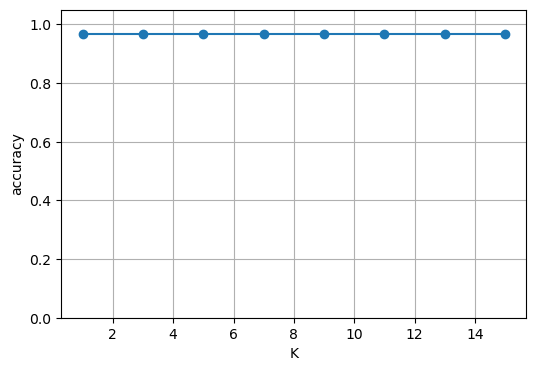

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667),
  np.float64(0.9666666666666667)])

In [34]:
x_train, y_train, x_test, y_test = chia_train_test(X_iris, Y_iris)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5
test_s = x_test_s[0]
khoang_cach = tinh_khoang_cach(test_s, x_train_s)
vi_tri_K = np.argsort(khoang_cach)[:K]
K_khoang_cach = khoang_cach[vi_tri_K]
K_nhan = y_train[vi_tri_K]
nhan_du_doan = du_doan_1_mau(test_s, x_train_s, y_train, K)
print("K khoảng cách nhỏ nhất:", K_khoang_cach)
print("Nhãn K láng giềng:", K_nhan)
print("Nhãn dự đoán:", nhan_du_doan)
print("Nhãn thật y_test[0]:", y_test[0])

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, K), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, K), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 1**

1. `X` có bao nhiêu dòng, bao nhiêu cột? Có bao nhiêu lớp?
2. Accuracy tại `K=5` khi có chuẩn hóa và khi không chuẩn hóa chênh nhau thế nào? Vì sao với Iris mức chênh thường nhỏ?
3. Vì sao không đưa cột `Id` vào feature?


In [7]:
# Bài 1
# 1. X có 150 dòng, 6 cột và 3 lớp Iris-setosa - 0, Iris-versicolor - 1, Iris-virginica - 2.
# 2. không chênh nhau nhiều lắm, huẩn hóa giúp các feature có cùng thang đo và tránh feature có giá trị lớn chi phối khoảng cách. 
# Tuy nhiên, với bộ dữ liệu Iris, các feature có phạm vi giá trị không quá chênh lệch và các lớp tương đối dễ phân biệt
# 3. Không đưa cột Id vào feature vì Id chỉ là mã định danh của mẫu dữ liệu,


---

# Bài 2 — Palmer Penguins

Nguồn: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

File `data/penguins_size.csv`. Đoán loài chim cánh cụt.

Cột: `species`, `island`, `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`, `sex`.

- Bỏ mọi dòng có ô trống hoặc `NA`.
- Nhãn là `species`.
- `island` và `sex` là chữ: `LabelEncoder` **từng cột**.
- Bốn cột đo là số: `culmen_length_mm`, `culmen_depth_mm`, `flipper_length_mm`, `body_mass_g`.
- Bắt buộc chuẩn hóa. `body_mass_g` khoảng vài nghìn, chiều dài mỏ khoảng vài chục. Không chuẩn hóa thì khoảng cách gần như chỉ còn khối lượng.


In [8]:
import kagglehub

# Download latest version
path1 = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")

print("Path to dataset files:", path1)

print(os.listdir(path1))
file_path1 = os.path.join(path1,'penguins_size.csv')
sepho1 = pd.read_csv(file_path)



Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\parulpandey\palmer-archipelago-antarctica-penguin-data\versions\1
['penguins_lter.csv', 'penguins_size.csv']


In [9]:
raw_pen = np.genfromtxt(file_path1, delimiter=',', dtype=str, skip_header=1)
print('trước khi bỏ dòng thiếu:', raw_pen.shape)

# TODO: bỏ dòng có '' hoặc 'NA', rồi tạo X_pen (float) và Y_pen (int)
valid = np.all((raw_pen != '') & (raw_pen != 'NA'), axis=1)
clean_pen = raw_pen[valid]
X_pen = clean_pen[:, 2:-1].astype(float)   # bỏ Id, lấy các feature
classes, Y_pen = np.unique(clean_pen[:, -1], return_inverse=True)
Y_pen = Y_pen.astype(int)       # cột cuối là nhãn

print('sau khi bỏ dòng thiếu:', X_pen.shape, Y_pen.shape)
print(np.unique(Y_pen, return_counts=True))


trước khi bỏ dòng thiếu: (344, 7)
sau khi bỏ dòng thiếu: (334, 4) (334,)
(array([0, 1, 2]), array([  1, 165, 168]))


In [10]:
clean_pen

array([['Adelie', 'Torgersen', '39.1', ..., '181', '3750', 'MALE'],
       ['Adelie', 'Torgersen', '39.5', ..., '186', '3800', 'FEMALE'],
       ['Adelie', 'Torgersen', '40.3', ..., '195', '3250', 'FEMALE'],
       ...,
       ['Gentoo', 'Biscoe', '50.4', ..., '222', '5750', 'MALE'],
       ['Gentoo', 'Biscoe', '45.2', ..., '212', '5200', 'FEMALE'],
       ['Gentoo', 'Biscoe', '49.9', ..., '213', '5400', 'MALE']],
      shape=(334, 7), dtype='<U9')

K khoảng cách nhỏ nhất: [0.171 0.183 0.234 0.252 0.253]
Nhãn K láng giềng: [1 1 1 1 2]
Nhãn dự đoán: 1
Nhãn thật y_test[0]: 1
accuracy K=5, đã chuẩn hóa: 0.9104477611940298
accuracy K=5, chưa chuẩn hóa: 0.7313432835820896
[(1, np.float64(0.896)), (3, np.float64(0.91)), (5, np.float64(0.91)), (7, np.float64(0.851)), (9, np.float64(0.896)), (11, np.float64(0.881)), (13, np.float64(0.881)), (15, np.float64(0.866))]


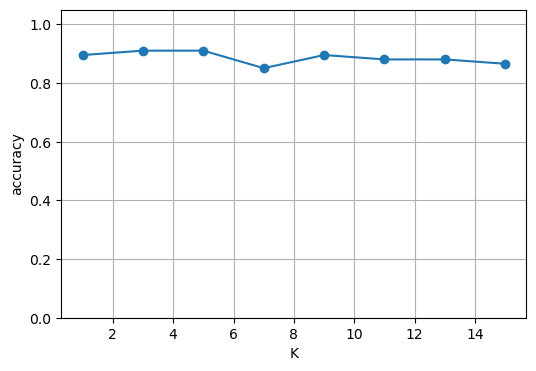

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.8955223880597015),
  np.float64(0.9104477611940298),
  np.float64(0.9104477611940298),
  np.float64(0.8507462686567164),
  np.float64(0.8955223880597015),
  np.float64(0.8805970149253731),
  np.float64(0.8805970149253731),
  np.float64(0.8656716417910447)])

In [11]:
x_train, y_train, x_test, y_test = chia_train_test(X_pen, Y_pen)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

K = 5
test_s = x_test_s[0]
khoang_cach = tinh_khoang_cach(test_s, x_train_s)
vi_tri_K = np.argsort(khoang_cach)[:K]
K_khoang_cach = khoang_cach[vi_tri_K]
K_nhan = y_train[vi_tri_K]
nhan_du_doan = du_doan_1_mau(test_s, x_train_s, y_train, K)
print("K khoảng cách nhỏ nhất:", K_khoang_cach)
print("Nhãn K láng giềng:", K_nhan)
print("Nhãn dự đoán:", nhan_du_doan)
print("Nhãn thật y_test[0]:", y_test[0])

print('accuracy K=5, đã chuẩn hóa:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
print('accuracy K=5, chưa chuẩn hóa:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))

ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 2**

1. Bỏ bao nhiêu dòng vì thiếu dữ liệu?
2. Accuracy `K=5` khi chưa chuẩn hóa thấp hơn bản đã chuẩn hóa ra sao? Cột nào kéo khoảng cách Euclid?
3. `K` nào cho accuracy cao nhất trên đồ thị?


In [12]:
# Bài 2
# 1. bỏ 10 dòng vì thiếu dữ liệu
# 2. thấp hơn khoảng 17.91 điểm %, cột body_mass_ do nó dùng đơn vị đo khác
# 3. K3


---

# Bài 3 — Heart Failure Prediction

Nguồn: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction

File `data/heart.csv`. 918 dòng. Đoán có bệnh tim hay không. Cùng kiểu bài với demo tình trạng xe.

Cột theo đúng thứ tự trong file:

`Age`, `Sex`, `ChestPainType`, `RestingBP`, `Cholesterol`, `FastingBS`, `RestingECG`, `MaxHR`, `ExerciseAngina`, `Oldpeak`, `ST_Slope`, `HeartDisease`.

- Nhãn `HeartDisease` đã là `0` / `1`.
- Cột chữ, `LabelEncoder` từng cột: `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.
- Cột số: `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, `Oldpeak`.
- Ghép các cột đã mã hóa thành một ma trận `X` kiểu float, rồi chuẩn hóa min–max.
- Hai lớp, nên các `K` đem thử là số lẻ.


In [23]:
import kagglehub

# Download latest version
path2 = kagglehub.dataset_download("fedesoriano/heart-failure-prediction")

print("Path to dataset files:", path2)
print(os.listdir(path2))
file_path2 = os.path.join(path2,'heart.csv')
raw_heart = np.genfromtxt(file_path2, delimiter=',', dtype=str, skip_header=1)


Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\fedesoriano\heart-failure-prediction\versions\1
['heart.csv']


In [25]:
from sklearn.preprocessing import LabelEncoder
heart_encoded = raw_heart.copy()
categorical_cols = [1, 2, 6, 8, 10]
for col in categorical_cols:
    le = LabelEncoder()
    heart_encoded[:, col] = le.fit_transform(heart_encoded[:, col])
    

In [26]:
print(raw_heart.shape)
print(raw_heart[0])

# TODO: X_heart float, Y_heart int
X_heart = heart_encoded[:, :-1].astype(float)
Y_heart = heart_encoded[:, -1].astype(int)

print(X_heart.shape, Y_heart.shape)
print(np.unique(Y_heart, return_counts=True))


(918, 12)
['40' 'M' 'ATA' '140' '289' '0' 'Normal' '172' 'N' '0' 'Up' '0']
(918, 11) (918,)
(array([0, 1]), array([410, 508]))


In [24]:
raw_heart

array([['40', 'M', 'ATA', ..., '0', 'Up', '0'],
       ['49', 'F', 'NAP', ..., '1', 'Flat', '1'],
       ['37', 'M', 'ATA', ..., '0', 'Up', '0'],
       ...,
       ['57', 'M', 'ASY', ..., '1.2', 'Flat', '1'],
       ['57', 'F', 'ATA', ..., '0', 'Flat', '1'],
       ['38', 'M', 'NAP', ..., '0', 'Up', '0']],
      shape=(918, 12), dtype='<U6')

accuracy K=5: 0.875
[(1, np.float64(0.87)), (3, np.float64(0.886)), (5, np.float64(0.875)), (7, np.float64(0.87)), (9, np.float64(0.87)), (11, np.float64(0.864)), (13, np.float64(0.87)), (15, np.float64(0.853))]


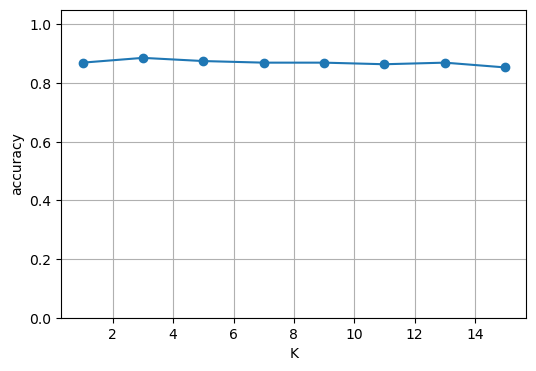

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(0.8695652173913043),
  np.float64(0.8858695652173914),
  np.float64(0.875),
  np.float64(0.8695652173913043),
  np.float64(0.8695652173913043),
  np.float64(0.8641304347826086),
  np.float64(0.8695652173913043),
  np.float64(0.8532608695652174)])

In [27]:
x_train, y_train, x_test, y_test = chia_train_test(X_heart, Y_heart)
x_train_s, x_test_s = chuan_hoa_minmax(x_train, x_test)

print('accuracy K=5:', accuracy(du_doan_tap(x_test_s, x_train_s, y_train, 5), y_test))
ve_accuracy_theo_K(x_train_s, y_train, x_test_s, y_test)


**Nộp kèm bài 3**

1. Có bao nhiêu người trong tập test? Tỉ lệ lớp `0` và `1` trên toàn bộ dữ liệu là bao nhiêu?
2. Accuracy cao nhất và `K` tương ứng?
3. Vì sao với bài 2 lớp nên chọn `K` lẻ?


In [ ]:
# Bài 3
# 1. 918 Lớp 0: 410/918×100=44.66% Lớp 1: 508/918×100=55.34%
# 2. 0.886 và K=3
# 3. nên chọn K lẻ để tránh trường hợp hai lớp có số phiếu bằng nhau khi sử dụng phương pháp bỏ phiếu đa số của KNN


---

# Bài 4 — Mushroom Classification

Nguồn: https://www.kaggle.com/datasets/uciml/mushroom-classification

File `data/mushrooms.csv`. Đoán nấm ăn được (`e`) hay độc (`p`).

Mọi cột đều là chữ, cùng kiểu demo xe. Cột 0 là nhãn `class`. Các cột còn lại là feature.

- Bỏ dòng nào còn giá trị `?`.
- `LabelEncoder` **từng cột** feature, rồi mã hóa riêng cột nhãn. Giống đoạn mã hóa trong demo xe.
- **Không** chuẩn hóa min–max. Mã `LabelEncoder` chỉ là tên nhóm được đánh số, không phải số đo cùng đơn vị.
- Tập này vài nghìn dòng. `tinh_khoang_cach` cần tính một lần cho cả `x_train` (vector), không viết vòng `for` từng dòng train.


In [29]:
import kagglehub

# Download latest version
path3 = kagglehub.dataset_download("uciml/mushroom-classification")

print("Path to dataset files:", path3)
print(os.listdir(path3))

file_path3 = os.path.join(path3,'mushrooms.csv')
raw_mush = np.genfromtxt(file_path3, delimiter=',', dtype=str, skip_header=1)

Path to dataset files: C:\Users\PC\.cache\kagglehub\datasets\uciml\mushroom-classification\versions\1
['mushrooms.csv']


In [30]:
raw_mush

array([['p', 'x', 's', ..., 'k', 's', 'u'],
       ['e', 'x', 's', ..., 'n', 'n', 'g'],
       ['e', 'b', 's', ..., 'n', 'n', 'm'],
       ...,
       ['e', 'f', 's', ..., 'b', 'c', 'l'],
       ['p', 'k', 'y', ..., 'w', 'v', 'l'],
       ['e', 'x', 's', ..., 'o', 'c', 'l']], shape=(8124, 23), dtype='<U1')

In [ ]:
print('trước khi bỏ dòng có ?:', raw_mush.shape)
valid = np.all(raw_mush != '?', axis=1)
clean_mush = raw_mush[valid]

# Mã hóa 22 feature, bỏ cột 0 là class
X_mush = np.empty((clean_mush.shape[0], clean_mush.shape[1] - 1), dtype=float)

for col in range(1, clean_mush.shape[1]):
    le = LabelEncoder()
    X_mush[:, col - 1] = le.fit_transform(clean_mush[:, col])

le_y = LabelEncoder()
Y_mush = le_y.fit_transform(clean_mush[:, 0]).astype(int)
print('sau khi bỏ dòng có ?:', X_mush.shape, Y_mush.shape)
print('Các lớp:', le_y.classes_)
print(np.unique(Y_mush, return_counts=True))

print(X_mush.shape, Y_mush.shape)
print(np.unique(Y_mush, return_counts=True))


trước khi bỏ dòng có ?: (8124, 23)
sau khi bỏ dòng có ?: (5644, 22) (5644,)
Các lớp: ['e' 'p']
(array([0, 1]), array([3488, 2156]))
(5644, 22) (5644,)
(array([0, 1]), array([3488, 2156]))


accuracy K=5: 0.9991142604074402
[(1, np.float64(1.0)), (3, np.float64(1.0)), (5, np.float64(0.999)), (7, np.float64(0.999)), (9, np.float64(0.997)), (11, np.float64(0.998)), (13, np.float64(0.996)), (15, np.float64(0.996))]


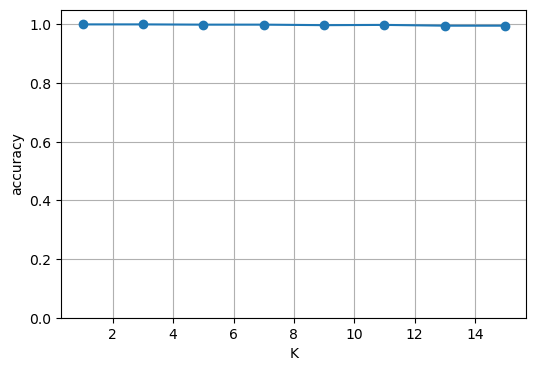

([1, 3, 5, 7, 9, 11, 13, 15],
 [np.float64(1.0),
  np.float64(1.0),
  np.float64(0.9991142604074402),
  np.float64(0.9991142604074402),
  np.float64(0.9973427812223207),
  np.float64(0.9982285208148804),
  np.float64(0.995571302037201),
  np.float64(0.995571302037201)])

In [32]:
x_train, y_train, x_test, y_test = chia_train_test(X_mush, Y_mush)

# Không gọi chuan_hoa_minmax
print('accuracy K=5:', accuracy(du_doan_tap(x_test, x_train, y_train, 5), y_test))
ve_accuracy_theo_K(x_train, y_train, x_test, y_test)


**Nộp kèm bài 4**

1. Còn bao nhiêu dòng sau khi bỏ `?`? Bao nhiêu feature?
2. Accuracy cao nhất và `K` tương ứng?
3. Bài này giống demo tình trạng xe ở bước nào, và khác bài 1–3 ở chỗ nào (chuẩn hóa)?


In [ ]:
# Bài 4
# 1. 5644 và 22 feature
# 2. Acc cao nhất là 1 với k tương ứng là 1, 3
# 3. Điểm giống: đều xử lý LabelEncoder để mã hóa riêng từng cột feature dạng chữ thành số, 
# Điểm khác biệt so với bài 1–3 là không chuẩn hóa Min–Max do các feature đều là dữ liệu phân loại